
# Embedding–RCI-S2 Association Analysis

This notebook evaluates whether residue-level embeddings from **ESM-2** and **ProtT5** contain signal associated with **RCI-S2**, before training more serious ML models.

## Main questions
1. Do embedding dimensions correlate with continuous **RCI-S2**?
2. Do residues with similar embeddings tend to have similar **RCI-S2**?
3. Do **flexible / context-dependent / rigid** residues separate in embedding space?
4. How well does a **simple linear probe** perform on continuous and multiclass targets?

## Expected inputs
For each model directory, the notebook expects:
- `X.npy`
- `y_class.npy`
- `y_rcis2.npy`
- `groups.npy`
- `metadata.csv` (optional but recommended)
- `label_mapping.json` (optional)

These files should come from the updated dataset builder.

## Notes
- Use **protein-level grouped splits** to avoid leakage.
- This notebook is for **association / signal analysis**, not final benchmarking.
- The aim is to justify whether training downstream models is biologically and statistically sensible.


In [19]:

# Core imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Optional imports
try:
    import seaborn as sns
    HAS_SNS = True
except ImportError:
    HAS_SNS = False

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

plt.rcParams["figure.figsize"] = (8, 5)

SEED = 42
np.random.seed(SEED)


/home/akshay-paliwal/anaconda3/envs/thesis/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Configuration
DATASETS = {
    "ESM2": "/home/akshay-paliwal/Documents/VUB/thesis_ai/data/dataset/esm2_multiclass",
    "ProtT5": "/home/akshay-paliwal/Documents/VUB/thesis_ai/data/dataset/protT5_multiclass",
}

# Optional: cap sample size for expensive visualizations
MAX_POINTS_FOR_EMBEDDING_PLOTS = 20000
MAX_POINTS_FOR_TSNE = 5000

# Number of top correlated dimensions to inspect
TOP_K_DIMS = 20

CLASS_NAMES = {
    0: "flexible",
    1: "context-dependent",
    2: "rigid",
}


In [3]:

def load_dataset(dataset_dir):
    X = np.load(os.path.join(dataset_dir, "X.npy"))
    y_class = np.load(os.path.join(dataset_dir, "y_class.npy"))
    y_rcis2 = np.load(os.path.join(dataset_dir, "y_rcis2.npy"))
    groups = np.load(os.path.join(dataset_dir, "groups.npy"), allow_pickle=True)

    metadata_path = os.path.join(dataset_dir, "metadata.csv")
    metadata = pd.read_csv(metadata_path) if os.path.exists(metadata_path) else None

    label_map_path = os.path.join(dataset_dir, "label_mapping.json")
    if os.path.exists(label_map_path):
        with open(label_map_path, "r") as f:
            label_mapping = json.load(f)
    else:
        label_mapping = None

    return {
        "X": X,
        "y_class": y_class,
        "y_rcis2": y_rcis2,
        "groups": groups,
        "metadata": metadata,
        "label_mapping": label_mapping,
    }


def grouped_train_test_split(X, y, groups, test_size=0.2, random_state=SEED):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(X, y, groups))
    return train_idx, test_idx


def summarize_dataset(name, ds):
    X = ds["X"]
    y_class = ds["y_class"]
    y_rcis2 = ds["y_rcis2"]
    groups = ds["groups"]

    unique_classes, class_counts = np.unique(y_class, return_counts=True)
    class_dist = {
        CLASS_NAMES[int(c)]: int(n) for c, n in zip(unique_classes, class_counts)
    }

    summary = {
        "dataset": name,
        "n_residues": X.shape[0],
        "embedding_dim": X.shape[1],
        "n_proteins": len(np.unique(groups)),
        "rcis2_mean": float(np.mean(y_rcis2)),
        "rcis2_std": float(np.std(y_rcis2)),
        "rcis2_min": float(np.min(y_rcis2)),
        "rcis2_max": float(np.max(y_rcis2)),
        "class_distribution": class_dist,
    }
    return summary


In [4]:

# Load all datasets
loaded = {name: load_dataset(path) for name, path in DATASETS.items()}

overview = pd.DataFrame([summarize_dataset(name, ds) for name, ds in loaded.items()])
overview


,dataset,n_residues,embedding_dim,n_proteins,rcis2_mean,rcis2_std,rcis2_min,rcis2_max,class_distribution
0,ESM2,444304,1280,4089,0.756963,0.189646,0.0617,0.9992,"{'flexible': 94773, 'context-dependent': 80953..."
1,ProtT5,444304,1024,4089,0.756963,0.189646,0.0617,0.9992,"{'flexible': 94773, 'context-dependent': 80953..."



## Interpretation guide

This table provides a quick structural summary of the embedding datasets.

Things to check:
- whether both models cover the same number of residues and proteins
- whether embedding dimensionality differs
- whether class distributions are skewed
- whether the continuous RCI-S2 range is preserved

If both datasets contain the same residues but different embeddings, then any differences in downstream association are attributable primarily to the representation rather than to the target data.


/tmp/ipykernel_111431/2385112451.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


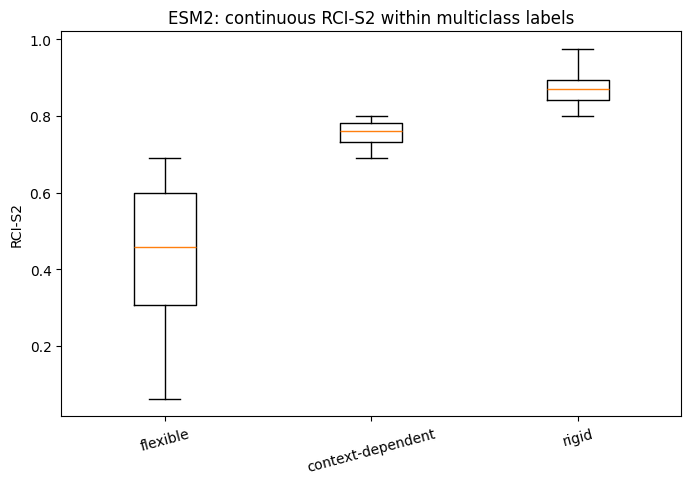

/tmp/ipykernel_111431/2385112451.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


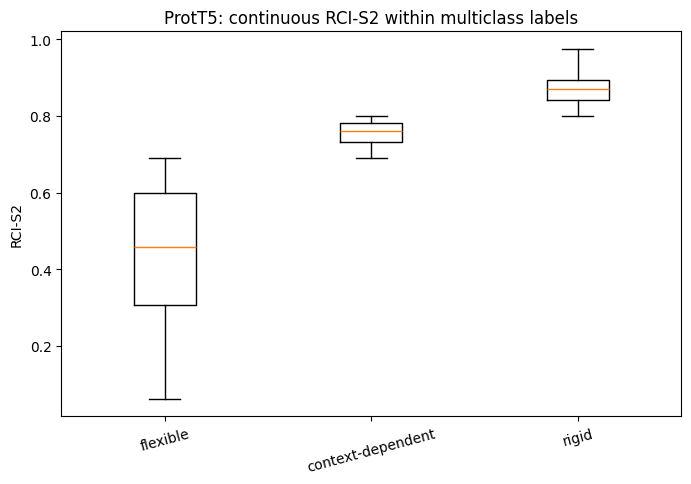

In [5]:

def plot_rcis2_by_class(name, ds):
    y_class = ds["y_class"]
    y_rcis2 = ds["y_rcis2"]

    plt.figure()
    data = [y_rcis2[y_class == c] for c in sorted(np.unique(y_class))]
    labels = [CLASS_NAMES[c] for c in sorted(np.unique(y_class))]
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.ylabel("RCI-S2")
    plt.title(f"{name}: continuous RCI-S2 within multiclass labels")
    plt.xticks(rotation=15)
    plt.show()

for name, ds in loaded.items():
    plot_rcis2_by_class(name, ds)



These plots act as a sanity check for the thresholded labels.

Expected pattern:
- **flexible** should occupy the lowest RCI-S2 range
- **context-dependent** should sit between the two extremes
- **rigid** should occupy the highest range

If this holds cleanly, then the class labels are behaving as intended and can be used for classification-style association analysis.


In [6]:

def compute_dimension_correlations(X, y, method="pearson"):
    corrs = []
    pvals = []
    for j in range(X.shape[1]):
        xj = X[:, j]
        if np.std(xj) == 0:
            corrs.append(np.nan)
            pvals.append(np.nan)
            continue

        if method == "pearson":
            r, p = pearsonr(xj, y)
        elif method == "spearman":
            r, p = spearmanr(xj, y)
        else:
            raise ValueError("method must be 'pearson' or 'spearman'")
        corrs.append(r)
        pvals.append(p)

    df = pd.DataFrame({
        "dim": np.arange(X.shape[1]),
        f"{method}_r": corrs,
        f"{method}_p": pvals,
        "abs_r": np.abs(corrs),
    }).sort_values("abs_r", ascending=False)

    return df


corr_results = {}
for name, ds in loaded.items():
    X = ds["X"]
    y = ds["y_rcis2"]

    pearson_df = compute_dimension_correlations(X, y, method="pearson")
    spearman_df = compute_dimension_correlations(X, y, method="spearman")

    corr_results[name] = {
        "pearson": pearson_df,
        "spearman": spearman_df,
    }

    print(f"\n{name} - top {TOP_K_DIMS} Pearson-correlated dims")
    display(pearson_df.head(TOP_K_DIMS))

    print(f"\n{name} - top {TOP_K_DIMS} Spearman-correlated dims")
    display(spearman_df.head(TOP_K_DIMS))



ESM2 - top 20 Pearson-correlated dims


,dim,pearson_r,pearson_p,abs_r
234,234,0.445308,0.0,0.445308
736,736,-0.393054,0.0,0.393054
690,690,-0.327841,0.0,0.327841
1160,1160,0.232158,0.0,0.232158
855,855,0.217451,0.0,0.217451
7,7,-0.209671,0.0,0.209671
980,980,-0.205283,0.0,0.205283
250,250,-0.204329,0.0,0.204329
125,125,-0.196168,0.0,0.196168
502,502,-0.195119,0.0,0.195119



ESM2 - top 20 Spearman-correlated dims


,dim,spearman_r,spearman_p,abs_r
234,234,0.402047,0.0,0.402047
736,736,-0.338215,0.0,0.338215
690,690,-0.314939,0.0,0.314939
855,855,0.246114,0.0,0.246114
1123,1123,-0.212902,0.0,0.212902
1160,1160,0.210175,0.0,0.210175
502,502,-0.201798,0.0,0.201798
156,156,-0.198071,0.0,0.198071
1262,1262,-0.197319,0.0,0.197319
370,370,0.187928,0.0,0.187928



ProtT5 - top 20 Pearson-correlated dims


,dim,pearson_r,pearson_p,abs_r
294,294,0.533250,0.0,0.533250
913,913,0.437683,0.0,0.437683
615,615,-0.337599,0.0,0.337599
886,886,-0.294038,0.0,0.294038
188,188,-0.289176,0.0,0.289176
32,32,0.281471,0.0,0.281471
857,857,0.258318,0.0,0.258318
947,947,-0.254217,0.0,0.254217
666,666,-0.230110,0.0,0.230110
1004,1004,-0.229543,0.0,0.229543



ProtT5 - top 20 Spearman-correlated dims


,dim,spearman_r,spearman_p,abs_r
294,294,0.401867,0.0,0.401867
615,615,-0.344528,0.0,0.344528
913,913,0.307811,0.0,0.307811
857,857,0.302043,0.0,0.302043
835,835,0.265237,0.0,0.265237
32,32,0.255502,0.0,0.255502
947,947,-0.254121,0.0,0.254121
1004,1004,-0.249382,0.0,0.249382
886,886,-0.237447,0.0,0.237447
666,666,-0.236675,0.0,0.236675


In [7]:

def summarize_correlation_strength(corr_df, method_label):
    vals = corr_df[method_label].dropna().values
    summary = {
        "n_dims": len(vals),
        "mean_abs_corr": float(np.mean(np.abs(vals))),
        "median_abs_corr": float(np.median(np.abs(vals))),
        "max_abs_corr": float(np.max(np.abs(vals))),
        "dims_abs_corr_ge_0.05": int(np.sum(np.abs(vals) >= 0.05)),
        "dims_abs_corr_ge_0.10": int(np.sum(np.abs(vals) >= 0.10)),
        "dims_abs_corr_ge_0.20": int(np.sum(np.abs(vals) >= 0.20)),
    }
    return summary


corr_strength_rows = []
for name, res in corr_results.items():
    pearson_summary = summarize_correlation_strength(res["pearson"], "pearson_r")
    pearson_summary["dataset"] = name
    pearson_summary["method"] = "Pearson"

    spearman_summary = summarize_correlation_strength(res["spearman"], "spearman_r")
    spearman_summary["dataset"] = name
    spearman_summary["method"] = "Spearman"

    corr_strength_rows.extend([pearson_summary, spearman_summary])

corr_strength_df = pd.DataFrame(corr_strength_rows)
corr_strength_df


,n_dims,mean_abs_corr,median_abs_corr,max_abs_corr,dims_abs_corr_ge_0.05,dims_abs_corr_ge_0.10,dims_abs_corr_ge_0.20,dataset,method
0,1280,0.051947,0.042481,0.445308,543,160,8,ESM2,Pearson
1,1280,0.052037,0.043230,0.402047,560,150,7,ESM2,Spearman
2,1024,0.050967,0.039357,0.533250,398,123,14,ProtT5,Pearson
3,1024,0.050748,0.038120,0.401867,407,122,17,ProtT5,Spearman


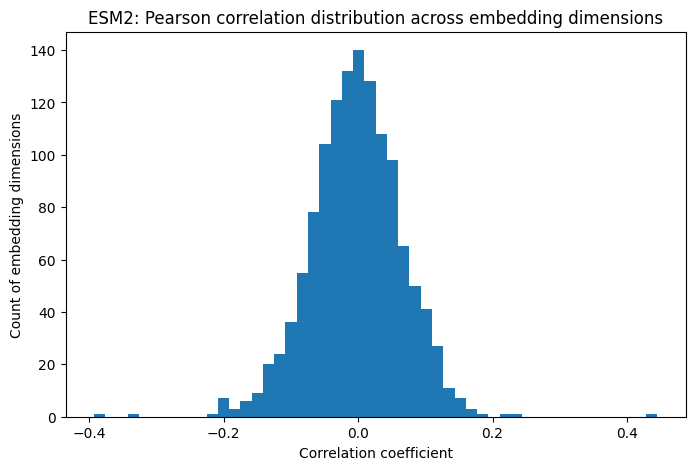

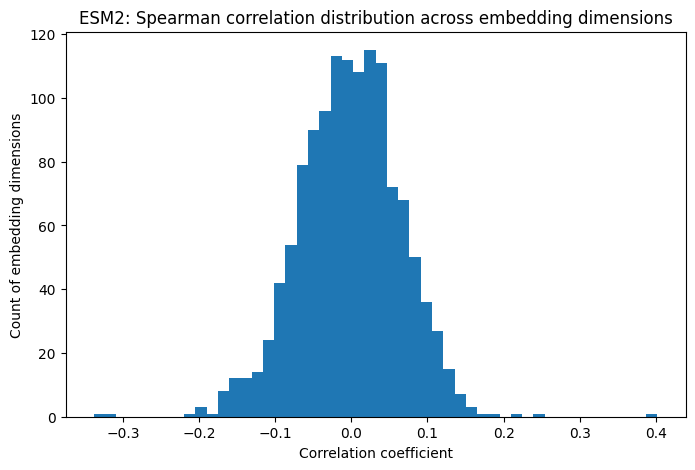

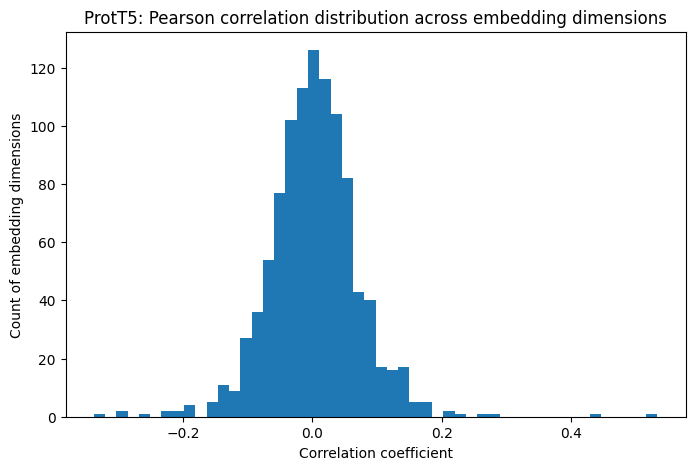

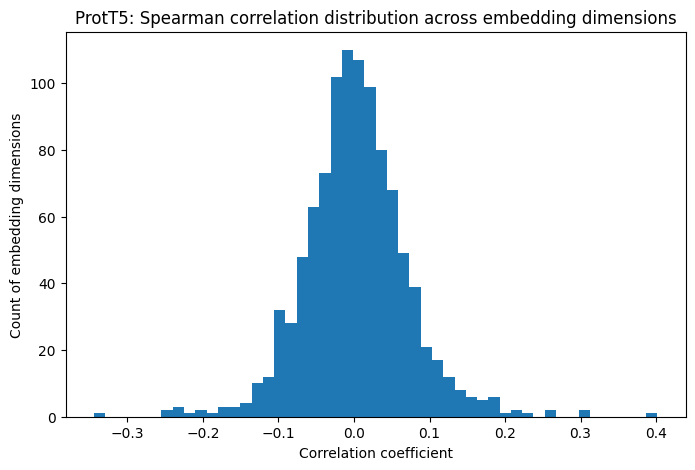

In [8]:

def plot_correlation_histograms(corr_df, value_col, title):
    plt.figure()
    plt.hist(corr_df[value_col].dropna(), bins=50)
    plt.xlabel("Correlation coefficient")
    plt.ylabel("Count of embedding dimensions")
    plt.title(title)
    plt.show()

for name, res in corr_results.items():
    plot_correlation_histograms(
        res["pearson"], "pearson_r", f"{name}: Pearson correlation distribution across embedding dimensions"
    )
    plot_correlation_histograms(
        res["spearman"], "spearman_r", f"{name}: Spearman correlation distribution across embedding dimensions"
    )



## How to read the dimension-correlation analysis

This section asks a simple question:

> Do individual embedding dimensions show any systematic relationship with continuous RCI-S2?

What to look for:
- If the strongest dimensions have **non-trivial absolute correlations**, then the embeddings likely encode useful target-related signal.
- If almost all dimensions cluster tightly near zero, then the target signal may be weak or highly distributed.
- Pearson captures **linear association**; Spearman captures **monotonic association**.

Useful interpretation:
- A few strong dimensions may indicate **specialized axes**
- Many weak-to-moderate correlated dimensions may indicate **distributed representation**
- Very weak correlations do **not** necessarily mean the embeddings are uninformative, since signal may emerge only in multivariate combinations


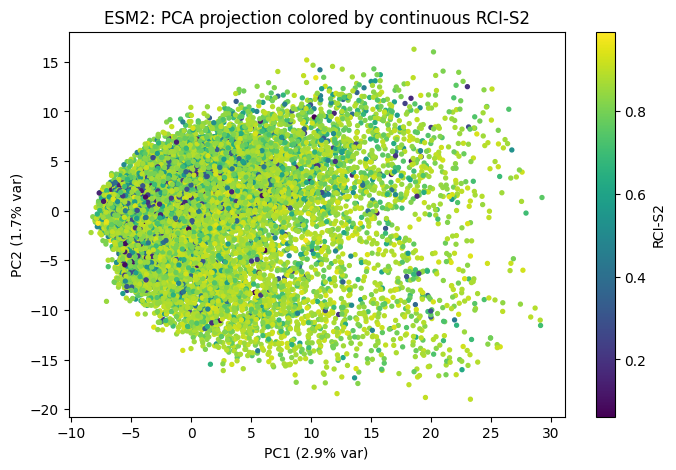

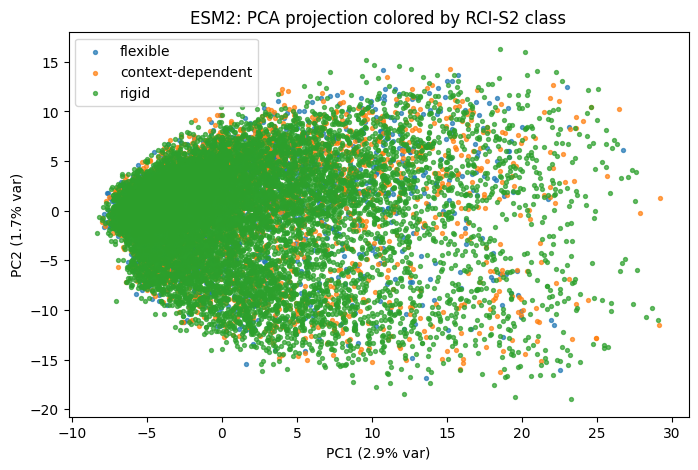

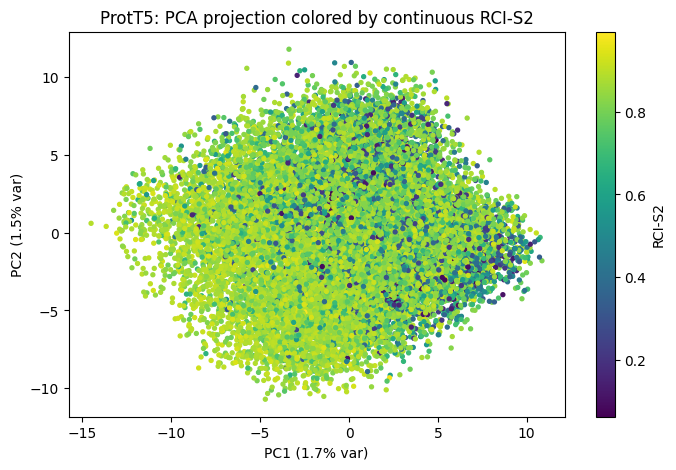

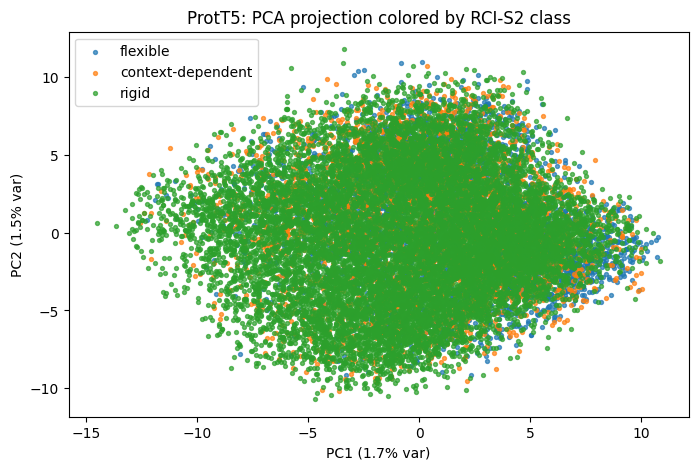

In [9]:

def pca_projection(X, n_components=2):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components, random_state=SEED)),
    ])
    Z = pipe.fit_transform(X)
    explained = pipe.named_steps["pca"].explained_variance_ratio_
    return Z, explained


def subsample_indices(n, max_points):
    if n <= max_points:
        return np.arange(n)
    return np.random.choice(n, size=max_points, replace=False)


for name, ds in loaded.items():
    X = ds["X"]
    y_rcis2 = ds["y_rcis2"]
    y_class = ds["y_class"]

    idx = subsample_indices(len(X), MAX_POINTS_FOR_EMBEDDING_PLOTS)
    Z, explained = pca_projection(X[idx], n_components=2)

    plt.figure()
    sc = plt.scatter(Z[:, 0], Z[:, 1], c=y_rcis2[idx], s=8)
    plt.colorbar(sc, label="RCI-S2")
    plt.xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
    plt.title(f"{name}: PCA projection colored by continuous RCI-S2")
    plt.show()

    plt.figure()
    for cls in sorted(np.unique(y_class)):
        mask = y_class[idx] == cls
        plt.scatter(Z[mask, 0], Z[mask, 1], s=8, label=CLASS_NAMES[cls], alpha=0.7)
    plt.xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
    plt.title(f"{name}: PCA projection colored by RCI-S2 class")
    plt.legend()
    plt.show()



## Interpretation of PCA plots

These visualizations do **not** prove predictive power on their own, but they are very useful qualitatively.

Possible outcomes:
- clear gradients of color across PCA space → embeddings carry target-related structure
- clear class grouping → embeddings separate rigid/flexible regimes at least partially
- strong overlap but smooth color transitions → target signal may be continuous rather than class-discrete
- almost no visible pattern → signal may be weak, nonlinear, or hidden in higher dimensions

Important caveat:
PCA emphasizes variance, not target relevance. A model can still perform well even if the first two principal components do not show clean separation.


/home/akshay-paliwal/anaconda3/envs/thesis/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


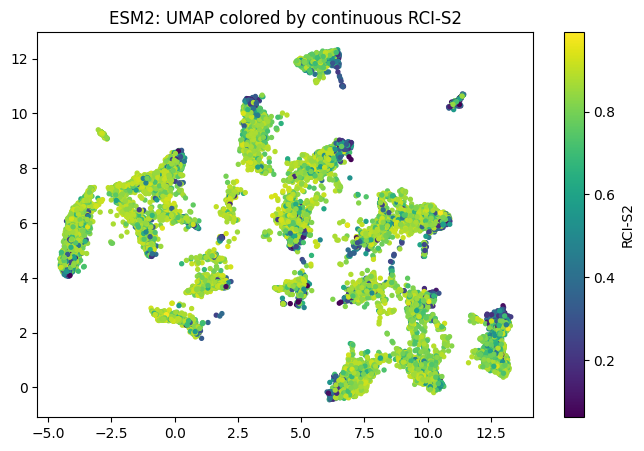

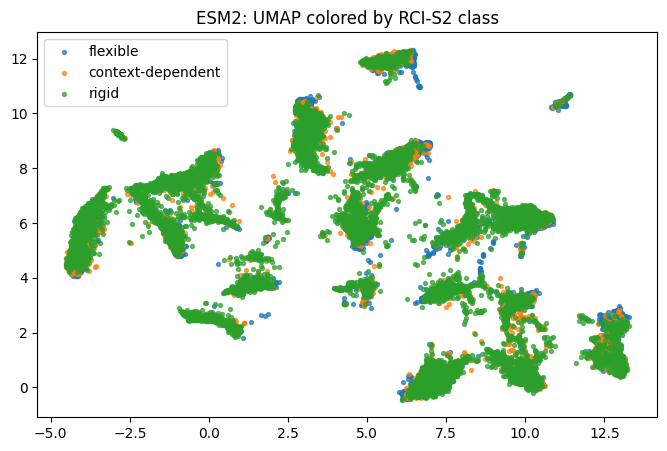

/home/akshay-paliwal/anaconda3/envs/thesis/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


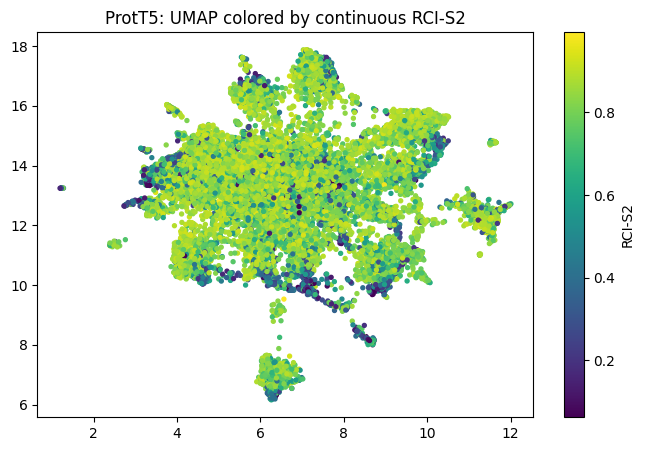

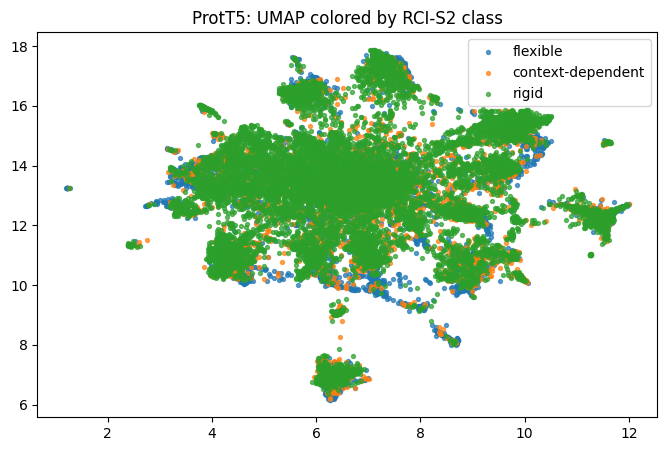

In [20]:

# Optional UMAP visualization
if HAS_UMAP:
    for name, ds in loaded.items():
        X = ds["X"]
        y_rcis2 = ds["y_rcis2"]
        y_class = ds["y_class"]

        idx = subsample_indices(len(X), MAX_POINTS_FOR_EMBEDDING_PLOTS)
        reducer = umap.UMAP(n_components=2, random_state=SEED)
        Z = reducer.fit_transform(X[idx])

        plt.figure()
        sc = plt.scatter(Z[:, 0], Z[:, 1], c=y_rcis2[idx], s=8)
        plt.colorbar(sc, label="RCI-S2")
        plt.title(f"{name}: UMAP colored by continuous RCI-S2")
        plt.show()

        plt.figure()
        for cls in sorted(np.unique(y_class)):
            mask = y_class[idx] == cls
            plt.scatter(Z[mask, 0], Z[mask, 1], s=8, label=CLASS_NAMES[cls], alpha=0.7)
        plt.title(f"{name}: UMAP colored by RCI-S2 class")
        plt.legend()
        plt.show()
else:
    print("UMAP not installed. Skipping UMAP visualizations.")


In [11]:

def knn_like_consistency(X, y, sample_size=2000):
    # Simple approximate neighbor consistency using cosine similarity via normalized dot product
    idx = subsample_indices(len(X), sample_size)
    Xs = X[idx]
    ys = y[idx]

    norms = np.linalg.norm(Xs, axis=1, keepdims=True) + 1e-8
    Xn = Xs / norms
    sim = Xn @ Xn.T
    np.fill_diagonal(sim, -np.inf)

    nn_idx = np.argmax(sim, axis=1)
    y_nn = ys[nn_idx]

    return {
        "sample_size": len(idx),
        "pearson_with_nn": float(np.corrcoef(ys, y_nn)[0, 1]),
        "mean_abs_diff_with_nn": float(np.mean(np.abs(ys - y_nn))),
    }


neighbor_rows = []
for name, ds in loaded.items():
    result = knn_like_consistency(ds["X"], ds["y_rcis2"], sample_size=2000)
    result["dataset"] = name
    neighbor_rows.append(result)

neighbor_df = pd.DataFrame(neighbor_rows)
neighbor_df


,sample_size,pearson_with_nn,mean_abs_diff_with_nn,dataset
0,2000,0.459006,0.150486,ESM2
1,2000,0.485055,0.118178,ProtT5



## Neighbor consistency interpretation

This test asks:

> If two residues have very similar embeddings, do they also tend to have similar RCI-S2 values?

This is a useful pre-ML sanity check because it probes whether target-related information is locally organized in representation space.

Interpretation:
- higher correlation with nearest-neighbor target values suggests stronger local structure in embedding space
- lower mean absolute difference suggests that nearby residues in representation space tend to share similar RCI-S2


In [12]:

def evaluate_linear_probe_regression(X, y, groups, alpha=1.0):
    train_idx, test_idx = grouped_train_test_split(X, y, groups)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha)),
    ])
    model.fit(X[train_idx], y[train_idx])
    pred = model.predict(X[test_idx])

    metrics = {
        "rmse": float(np.sqrt(mean_squared_error(y[test_idx], pred))),
        "mae": float(mean_absolute_error(y[test_idx], pred)),
        "r2": float(r2_score(y[test_idx], pred)),
        "pearson_pred_target": float(np.corrcoef(y[test_idx], pred)[0, 1]),
    }
    return metrics, y[test_idx], pred


regression_rows = []
regression_predictions = {}

for name, ds in loaded.items():
    metrics, y_true, y_pred = evaluate_linear_probe_regression(ds["X"], ds["y_rcis2"], ds["groups"])
    metrics["dataset"] = name
    regression_rows.append(metrics)
    regression_predictions[name] = (y_true, y_pred)

regression_df = pd.DataFrame(regression_rows)
regression_df


/home/akshay-paliwal/anaconda3/envs/thesis/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.1024422203197446e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,rmse,mae,r2,pearson_pred_target,dataset
0,0.116906,0.082320,0.620942,0.788041,ESM2
1,0.117082,0.080792,0.619805,0.787330,ProtT5


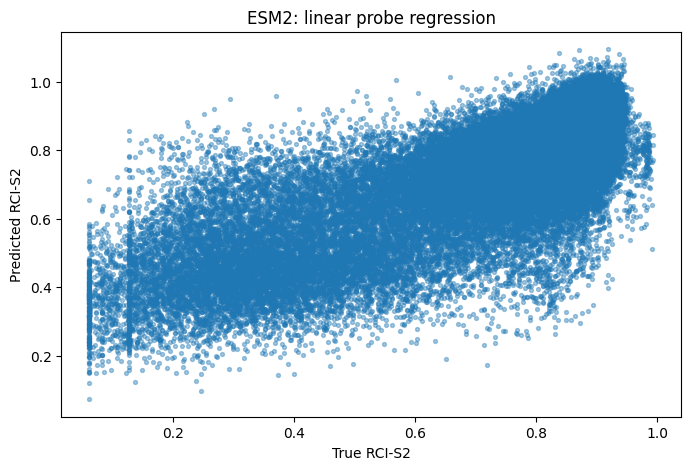

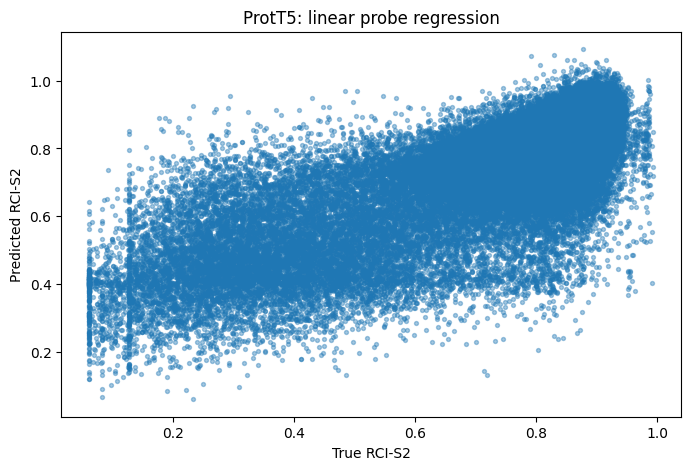

In [13]:

for name, (y_true, y_pred) in regression_predictions.items():
    plt.figure()
    plt.scatter(y_true, y_pred, s=8, alpha=0.4)
    plt.xlabel("True RCI-S2")
    plt.ylabel("Predicted RCI-S2")
    plt.title(f"{name}: linear probe regression")
    plt.show()



## Linear regression probe interpretation

This is one of the most important sections.

A linear probe tests whether **RCI-S2 can be recovered from the embedding with a simple linear mapping**.

Why it matters:
- good linear-probe performance suggests the signal is already present in an accessible form
- poor linear-probe performance does **not** mean the embeddings are useless, but suggests the signal may be nonlinear, weak, or highly distributed

How to read metrics:
- lower **RMSE/MAE** is better
- higher **R²** is better
- higher prediction-target Pearson correlation is better

If one embedding model consistently outperforms the other here, that is already a strong pre-ML comparison result.


In [15]:
def evaluate_linear_probe_classification(X, y_class, groups, max_iter=1000):
    train_idx, test_idx = grouped_train_test_split(X, y_class, groups)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=max_iter,
            class_weight="balanced",
            random_state=SEED
        )),
    ])

    model.fit(X[train_idx], y_class[train_idx])
    pred = model.predict(X[test_idx])

    metrics = {
        "accuracy": float(accuracy_score(y_class[test_idx], pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_class[test_idx], pred)),
        "macro_f1": float(f1_score(y_class[test_idx], pred, average="macro")),
        "weighted_f1": float(f1_score(y_class[test_idx], pred, average="weighted")),
    }

    report = classification_report(
        y_class[test_idx],
        pred,
        labels=[0, 1, 2],
        target_names=[CLASS_NAMES[c] for c in [0, 1, 2]],
        output_dict=True,
        zero_division=0,
    )

    cm = confusion_matrix(y_class[test_idx], pred, labels=[0, 1, 2])
    return metrics, report, cm


classification_rows = []
classification_reports = {}
classification_cms = {}

for name, ds in loaded.items():
    metrics, report, cm = evaluate_linear_probe_classification(ds["X"], ds["y_class"], ds["groups"])
    metrics["dataset"] = name
    classification_rows.append(metrics)
    classification_reports[name] = pd.DataFrame(report).T
    classification_cms[name] = cm

classification_df = pd.DataFrame(classification_rows)
classification_df


,accuracy,balanced_accuracy,macro_f1,weighted_f1,dataset
0,0.712596,0.701265,0.675866,0.730197,ESM2
1,0.705950,0.701232,0.673143,0.725191,ProtT5



ESM2 classification report


,precision,recall,f1-score,support
flexible,0.734794,0.755631,0.745067,18513.000000
context-dependent,0.392126,0.623173,0.481360,16286.000000
rigid,0.895241,0.724991,0.801171,53220.000000
accuracy,0.712596,0.712596,0.712596,0.712596
macro avg,0.674054,0.701265,0.675866,88019.000000
weighted avg,0.768404,0.712596,0.730197,88019.000000


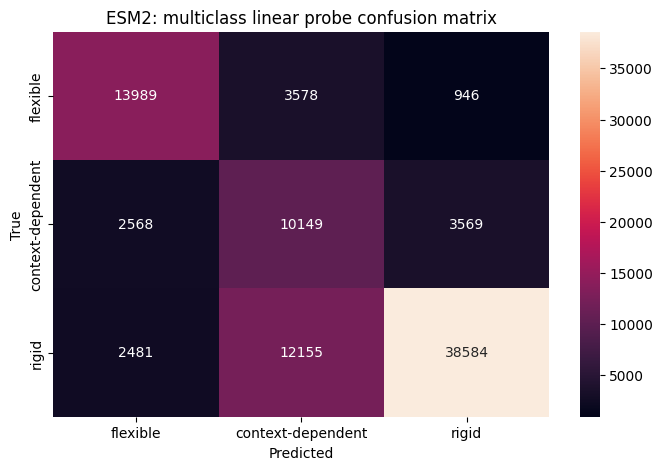


ProtT5 classification report


,precision,recall,f1-score,support
flexible,0.737125,0.747637,0.742344,18513.00000
context-dependent,0.386922,0.646383,0.484078,16286.00000
rigid,0.898513,0.709677,0.793008,53220.00000
accuracy,0.705950,0.705950,0.705950,0.70595
macro avg,0.674187,0.701232,0.673143,88019.00000
weighted avg,0.769910,0.705950,0.725191,88019.00000


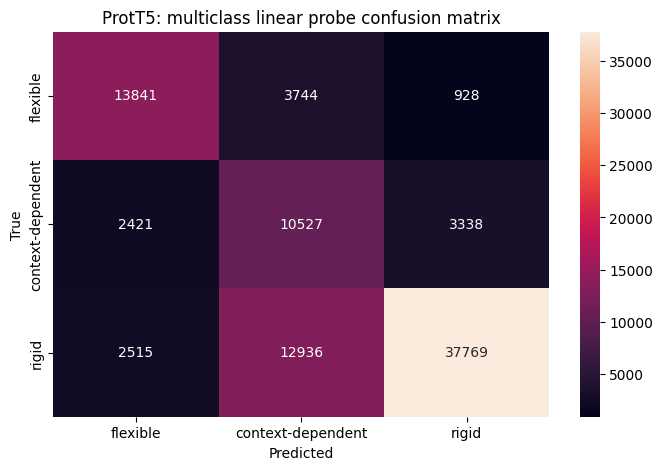

In [21]:

for name, report_df in classification_reports.items():
    print(f"\n{name} classification report")
    display(report_df)

    plt.figure()
    cm = classification_cms[name]
    if HAS_SNS:
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            xticklabels=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
            yticklabels=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
        )
    else:
        plt.imshow(cm)
        plt.xticks(range(len(CLASS_NAMES)), [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)], rotation=20)
        plt.yticks(range(len(CLASS_NAMES)), [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)])
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name}: multiclass linear probe confusion matrix")
    plt.show()



## Multiclass linear probe interpretation

This classification probe tests whether the embeddings linearly separate the three biologically motivated regimes:
- flexible
- context-dependent
- rigid

Why **balanced accuracy** and **macro F1** matter:
Your dataset is likely class-imbalanced, so raw accuracy may overstate performance by favoring the largest class.

Useful patterns:
- good rigid vs flexible separation but poor context-dependent separation is a very plausible and biologically sensible outcome
- confusion concentrated around the context-dependent class may indicate that this middle regime is genuinely transitional rather than sharply separable


,class,pc1_mean,pc2_mean,n
0,flexible,-1.923313,0.731443,4272
1,context-dependent,0.155446,0.705522,3640
2,rigid,0.632906,-0.470949,12088


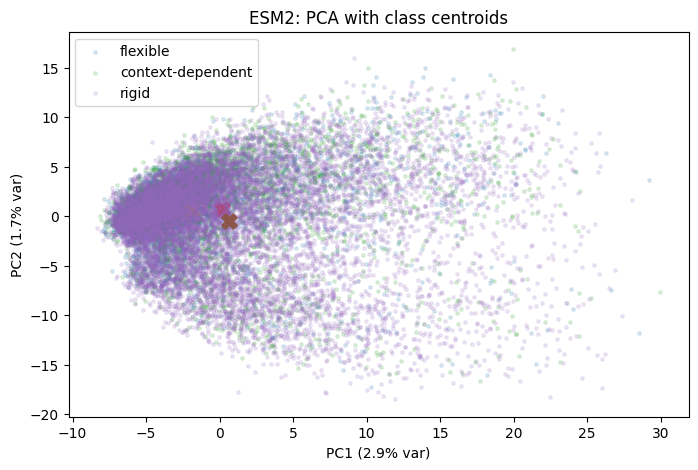

,class,pc1_mean,pc2_mean,n
0,flexible,1.969032,0.434931,4219
1,context-dependent,0.452655,0.273639,3659
2,rigid,-0.821945,-0.233973,12122


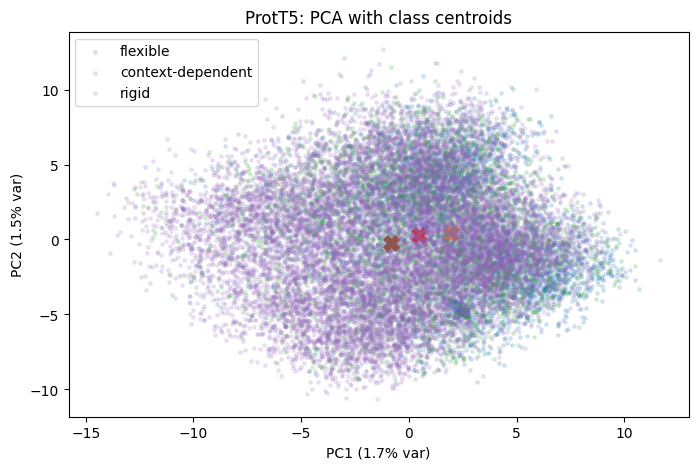

In [17]:

# Optional: inspect PCA centroids per class
def plot_class_centroids_in_pca(name, ds):
    X = ds["X"]
    y_class = ds["y_class"]

    idx = subsample_indices(len(X), MAX_POINTS_FOR_EMBEDDING_PLOTS)
    Z, explained = pca_projection(X[idx], n_components=2)

    centroid_rows = []
    for cls in sorted(np.unique(y_class[idx])):
        mask = y_class[idx] == cls
        centroid_rows.append({
            "class": CLASS_NAMES[cls],
            "pc1_mean": Z[mask, 0].mean(),
            "pc2_mean": Z[mask, 1].mean(),
            "n": int(mask.sum())
        })
    centroids = pd.DataFrame(centroid_rows)
    display(centroids)

    plt.figure()
    for cls in sorted(np.unique(y_class[idx])):
        mask = y_class[idx] == cls
        plt.scatter(Z[mask, 0], Z[mask, 1], s=6, alpha=0.15, label=CLASS_NAMES[cls])
        plt.scatter(Z[mask, 0].mean(), Z[mask, 1].mean(), s=120, marker="X")
    plt.xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
    plt.title(f"{name}: PCA with class centroids")
    plt.legend()
    plt.show()

for name, ds in loaded.items():
    plot_class_centroids_in_pca(name, ds)



## Final synthesis template

Use the results above to answer the central pre-ML question:

> Do residue-level embeddings contain information associated with RCI-S2?

A strong conclusion would usually look like this:
- dimension-level correlations are non-zero and not purely random
- PCA/UMAP visualizations show at least partial target organization
- nearest-neighbor consistency is better than chance
- a simple linear probe achieves meaningful predictive performance
- one model may outperform the other, suggesting better encoding of local flexibility/order-related information

A more cautious conclusion would look like this:
- individual dimensions correlate weakly, but multivariate linear probes still recover some signal
- rigid and flexible classes separate better than the context-dependent class
- the middle class may remain ambiguous because it reflects transitional or context-sensitive residues

This is exactly the sort of evidence you want before moving into more complex models such as MLPs, CNNs, or sequence-aware architectures.


In [18]:

# Auto-generated narrative summary
def narrative_summary(name, ds, corr_res, neighbor_row, reg_row, clf_row):
    pearson = summarize_correlation_strength(corr_res["pearson"], "pearson_r")
    spearman = summarize_correlation_strength(corr_res["spearman"], "spearman_r")

    lines = []
    lines.append(f"### {name}")
    lines.append("")
    lines.append(
        f"- The dataset contains {ds['X'].shape[0]:,} residues across {len(np.unique(ds['groups'])):,} proteins, "
        f"with embedding dimension {ds['X'].shape[1]}."
    )
    lines.append(
        f"- Dimension-level association with continuous RCI-S2 is summarized by a maximum absolute Pearson correlation of "
        f"{pearson['max_abs_corr']:.3f} and a maximum absolute Spearman correlation of {spearman['max_abs_corr']:.3f}."
    )
    lines.append(
        f"- The representation-space neighbor consistency analysis gave a nearest-neighbor Pearson correlation of "
        f"{neighbor_row['pearson_with_nn']:.3f} with a mean absolute RCI-S2 difference of {neighbor_row['mean_abs_diff_with_nn']:.3f}."
    )
    lines.append(
        f"- The grouped linear regression probe achieved RMSE={reg_row['rmse']:.3f}, MAE={reg_row['mae']:.3f}, "
        f"R²={reg_row['r2']:.3f}, and prediction-target Pearson correlation={reg_row['pearson_pred_target']:.3f}."
    )
    lines.append(
        f"- The grouped multiclass linear probe achieved accuracy={clf_row['accuracy']:.3f}, "
        f"balanced accuracy={clf_row['balanced_accuracy']:.3f}, macro-F1={clf_row['macro_f1']:.3f}, "
        f"and weighted-F1={clf_row['weighted_f1']:.3f}."
    )
    lines.append(
        "- Overall interpretation: if the linear probes and neighbor consistency metrics are meaningfully above weak baselines, "
        "then the embeddings contain usable RCI-S2-related signal and justify moving to richer models."
    )
    return "\n".join(lines)


summary_chunks = []
for name, ds in loaded.items():
    neighbor_row = neighbor_df[neighbor_df["dataset"] == name].iloc[0].to_dict()
    reg_row = regression_df[regression_df["dataset"] == name].iloc[0].to_dict()
    clf_row = classification_df[classification_df["dataset"] == name].iloc[0].to_dict()

    summary_chunks.append(
        narrative_summary(name, ds, corr_results[name], neighbor_row, reg_row, clf_row)
    )

from IPython.display import Markdown, display
display(Markdown("\n\n".join(summary_chunks)))


### ESM2

- The dataset contains 444,304 residues across 4,089 proteins, with embedding dimension 1280.
- Dimension-level association with continuous RCI-S2 is summarized by a maximum absolute Pearson correlation of 0.445 and a maximum absolute Spearman correlation of 0.402.
- The representation-space neighbor consistency analysis gave a nearest-neighbor Pearson correlation of 0.459 with a mean absolute RCI-S2 difference of 0.150.
- The grouped linear regression probe achieved RMSE=0.117, MAE=0.082, R²=0.621, and prediction-target Pearson correlation=0.788.
- The grouped multiclass linear probe achieved accuracy=0.713, balanced accuracy=0.701, macro-F1=0.676, and weighted-F1=0.730.
- Overall interpretation: if the linear probes and neighbor consistency metrics are meaningfully above weak baselines, then the embeddings contain usable RCI-S2-related signal and justify moving to richer models.

### ProtT5

- The dataset contains 444,304 residues across 4,089 proteins, with embedding dimension 1024.
- Dimension-level association with continuous RCI-S2 is summarized by a maximum absolute Pearson correlation of 0.533 and a maximum absolute Spearman correlation of 0.402.
- The representation-space neighbor consistency analysis gave a nearest-neighbor Pearson correlation of 0.485 with a mean absolute RCI-S2 difference of 0.118.
- The grouped linear regression probe achieved RMSE=0.117, MAE=0.081, R²=0.620, and prediction-target Pearson correlation=0.787.
- The grouped multiclass linear probe achieved accuracy=0.706, balanced accuracy=0.701, macro-F1=0.673, and weighted-F1=0.725.
- Overall interpretation: if the linear probes and neighbor consistency metrics are meaningfully above weak baselines, then the embeddings contain usable RCI-S2-related signal and justify moving to richer models.


## Suggested next step

After running this notebook, the next notebook should move from **association** to **modeling**:
1. grouped train/validation/test setup
2. linear baseline
3. small MLP
4. neighborhood-aware model (windowed MLP or 1D CNN)
5. comparison across ESM-2 and ProtT5

At that point, you will already know whether the models are learning from a plausible signal rather than from a weak or arbitrary target.
